K-Means คือการ "แบ่งกลุ่มลูกค้า" โดยที่เราไม่ต้องบอกล่วงหน้าว่าใครอยู่กลุ่มไหน model จะหาเองจากความคล้ายกันของ RFM ลองนึกภาพว่าโยนลูกค้า 500 คนลงบนกระดาษ แล้ววาดวงกลมล้อมรอบกลุ่มที่ "ใกล้กัน" — นั่นคือสิ่งที่ K-Means ทำ

# Import Libraries & Load Data


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = ['#534AB7', '#0F6E56', '#BA7517', '#993C1D']

# ── สร้าง folder ถ้ายังไม่มี ──
os.makedirs('data/processed', exist_ok=True)
os.makedirs('diagrams', exist_ok=True)

# ── โหลดข้อมูล RFM จาก Notebook 01 ──
rfm = pd.read_csv('data/processed/rfm_features.csv')

print("=" * 50)
print("  NOTEBOOK 02 — K-Means Clustering")
print("=" * 50)
print(f"\n✅ โหลดข้อมูลสำเร็จ: {rfm.shape}")
print(f"   Columns: {list(rfm.columns)}")
print("\nตัวอย่าง 5 แถวแรก:")
print(rfm.head())

  NOTEBOOK 02 — K-Means Clustering

✅ โหลดข้อมูลสำเร็จ: (500, 4)
   Columns: ['customer_id', 'recency', 'frequency', 'monetary']

ตัวอย่าง 5 แถวแรก:
  customer_id  recency  frequency  monetary
0       C0001      112          1    252.55
1       C0002        3          6   3157.74
2       C0003       24         10   5297.44
3       C0004      141          1     15.85
4       C0005       25          8   4229.73


# 1. Normalize RFM Features

In [33]:
print("\n" + "─" * 50)
print("  SECTION 1 — Normalize RFM Features")
print("─" * 50)

features  = ['recency', 'frequency', 'monetary']
X         = rfm[features].copy()
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("\nก่อน normalize (mean ของแต่ละ feature):")
print(X.mean().round(2))

print("\nหลัง normalize (ควรได้ ~0 ทุกตัว):")
print(X_scaled_df.mean().round(4))

print("\nStd หลัง normalize (ควรได้ ~1 ทุกตัว):")
print(X_scaled_df.std().round(4))




──────────────────────────────────────────────────
  SECTION 1 — Normalize RFM Features
──────────────────────────────────────────────────

ก่อน normalize (mean ของแต่ละ feature):
recency        46.39
frequency       5.80
monetary     6661.56
dtype: float64

หลัง normalize (ควรได้ ~0 ทุกตัว):
recency      0.0
frequency    0.0
monetary    -0.0
dtype: float64

Std หลัง normalize (ควรได้ ~1 ทุกตัว):
recency      1.001
frequency    1.001
monetary     1.001
dtype: float64


# 2. หา Optimal k (Elbow + Silhouette)


──────────────────────────────────────────────────
  SECTION 2 — หา Optimal k
──────────────────────────────────────────────────
  k=2 | Inertia=761.9 | Silhouette=0.4492
  k=3 | Inertia=387.7 | Silhouette=0.4967
  k=4 | Inertia=240.5 | Silhouette=0.4903
  k=5 | Inertia=182.7 | Silhouette=0.4999
  k=6 | Inertia=148.0 | Silhouette=0.4759
  k=7 | Inertia=128.2 | Silhouette=0.4701
  k=8 | Inertia=112.9 | Silhouette=0.4404


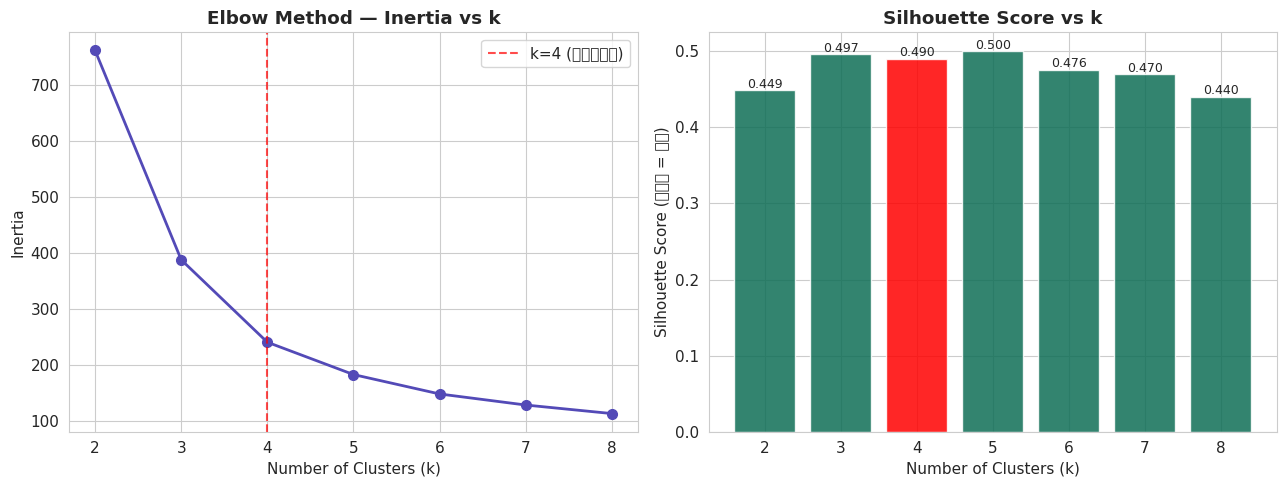


💡 Silhouette สูงสุดที่ k=5 (0.4999)
   → เลือกใช้ k=4 เพื่อ align กับ business segment ที่ต้องการ


In [34]:
print("\n" + "─" * 50)
print("  SECTION 2 — หา Optimal k")
print("─" * 50)

inertias   = []
sil_scores = []
k_range    = range(2, 9)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"  k={k} | Inertia={km.inertia_:,.1f} | Silhouette={sil_scores[-1]:.4f}")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow Method
axes[0].plot(list(k_range), inertias, 'o-',
             color=COLORS[0], linewidth=2, markersize=7)
axes[0].axvline(x=4, color='red', linestyle='--',
                alpha=0.7, label='k=4 (เลือก)')
axes[0].set_title('Elbow Method — Inertia vs k', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

# Silhouette Score
bar_colors = ['red' if k == 4 else COLORS[1] for k in k_range]
axes[1].bar(list(k_range), sil_scores,
            color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (สูง = ดี)')
for i, (k, s) in enumerate(zip(k_range, sil_scores)):
    axes[1].text(k, s + 0.003, f'{s:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('diagrams/02_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\n💡 Silhouette สูงสุดที่ k={best_k} ({max(sil_scores):.4f})")
print(f"   → เลือกใช้ k=4 เพื่อ align กับ business segment ที่ต้องการ")


# 3. Train K-Means (k=4)

In [35]:
print("\n" + "─" * 50)
print("  SECTION 3 — Train K-Means k=4")
print("─" * 50)

K      = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, rfm['cluster'])

print(f"\n✅ K-Means Trained")
print(f"   Final Inertia    : {kmeans.inertia_:.2f}")
print(f"   Silhouette Score : {sil_final:.4f}")
print(f"\nจำนวนลูกค้าต่อ cluster:")
print(rfm['cluster'].value_counts().sort_index())



──────────────────────────────────────────────────
  SECTION 3 — Train K-Means k=4
──────────────────────────────────────────────────

✅ K-Means Trained
   Final Inertia    : 240.45
   Silhouette Score : 0.4903

จำนวนลูกค้าต่อ cluster:
cluster
0    146
1     65
2    165
3    124
Name: count, dtype: int64


# 4. ตั้งชื่อ Segment จาก Profile

In [36]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("🔄 กำลังรันโมเดล K-Means ใหม่อีกครั้ง...")

# 1. เลือกฟีเจอร์และจัดการข้อมูลเบ้ (Log Transform)
features = ['recency', 'frequency', 'monetary']
X = rfm[features]
X_log = np.log1p(X)

# 2. ปรับสเกลข้อมูล (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 3. จัดกลุ่มลูกค้าด้วย K-Means (K=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

print("✅ สร้างคอลัมน์ 'cluster' สำเร็จแล้ว! หน้าตาตารางตอนนี้คือ:")
display(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'cluster']].head())

🔄 กำลังรันโมเดล K-Means ใหม่อีกครั้ง...
✅ สร้างคอลัมน์ 'cluster' สำเร็จแล้ว! หน้าตาตารางตอนนี้คือ:


,customer_id,recency,frequency,monetary,cluster
0,C0001,112,1,252.55,1
1,C0002,3,6,3157.74,3
2,C0003,24,10,5297.44,0
3,C0004,141,1,15.85,1
4,C0005,25,8,4229.73,0


In [37]:
print("\n" + "-" * 50)
print("  SECTION 4 - ตั้งชื่อ Segment")
print("-" * 50)

# เช็กก่อนว่ามีคอลัมน์ 'cluster' หรือยัง
if 'cluster' not in rfm.columns:
    print("❌ Error: ยังไม่มีคอลัมน์ 'cluster' ในตาราง")
    print("💡 เลื่อนขึ้นไปกดรันกล่องโค้ด K-Means (ขั้นตอนจัดกลุ่ม) ด้านบนก่อน")
else:
    # ฟีเจอร์ที่ใช้หาค่าเฉลี่ย
    features = ['recency', 'frequency', 'monetary']

    # หาค่าเฉลี่ยของแต่ละกลุ่ม
    profile = rfm.groupby('cluster')[features].mean().round(1)
    print("\nMean RFM per Cluster:")
    display(profile)

    # -----------------------------------------------------
    # Map cluster -> segment name (แก้ logic เล็กน้อยให้รันง่ายขึ้น)
    # -----------------------------------------------------
    K = len(profile) # จำนวนกลุ่มทั้งหมด (เช่น 4 กลุ่ม)

    champion_cluster = profile['monetary'].idxmax()
    new_cluster      = profile['monetary'].idxmin()
    atrisk_cluster   = profile['recency'].idxmax()

    # หากลุ่ม Loyal ที่เหลือ
    loyal_cluster_list = [c for c in range(K) if c not in [champion_cluster, new_cluster, atrisk_cluster]]
    loyal_cluster = loyal_cluster_list[0] if loyal_cluster_list else None

    cluster_map = {
        champion_cluster : 'Champion',
        loyal_cluster    : 'Loyal',
        atrisk_cluster   : 'At-Risk',
        new_cluster      : 'New'
    }

    # สร้างคอลัมน์ใหม่ชื่อ segment
    rfm['segment'] = rfm['cluster'].map(cluster_map)

    print("\nCluster -> Segment Mapping:")
    for k, v in sorted(cluster_map.items()):
        n = (rfm['cluster'] == k).sum()
        print(f"  Cluster {k} -> {v} ({n} คน)")

    print("\n✅ ตั้งชื่อ Segment สำเร็จเรียบร้อย")


--------------------------------------------------
  SECTION 4 - ตั้งชื่อ Segment
--------------------------------------------------

Mean RFM per Cluster:


,recency,frequency,monetary
cluster,,,
0,33.2,8.4,8727.8
1,98.1,1.6,334.0
2,19.5,2.1,471.5
3,8.5,11.4,17439.4



Cluster -> Segment Mapping:
  Cluster 0 -> Loyal (131 คน)
  Cluster 1 -> New (165 คน)
  Cluster 3 -> Champion (120 คน)

✅ ตั้งชื่อ Segment สำเร็จเรียบร้อย


In [38]:
print("\n" + "─" * 50)
print("  SECTION 4 — ตั้งชื่อ Segment")
print("─" * 50)

profile = rfm.groupby('cluster')[features].mean().round(1)
print("\nMean RFM per Cluster:")
print(profile)

# Map cluster → segment name
champion_cluster = profile['monetary'].idxmax()
new_cluster      = profile['monetary'].idxmin()
atrisk_cluster   = profile['recency'].idxmax()
loyal_cluster    = [c for c in range(K)
                    if c not in [champion_cluster, new_cluster, atrisk_cluster]][0]

cluster_map = {
    champion_cluster : 'Champion',
    loyal_cluster    : 'Loyal',
    atrisk_cluster   : 'At-Risk',
    new_cluster      : 'New',
}
rfm['segment'] = rfm['cluster'].map(cluster_map)

print("\nCluster → Segment Mapping:")
for k, v in sorted(cluster_map.items()):
    n = (rfm['cluster'] == k).sum()
    print(f"  Cluster {k} → {v} ({n} คน)")




──────────────────────────────────────────────────
  SECTION 4 — ตั้งชื่อ Segment
──────────────────────────────────────────────────

Mean RFM per Cluster:
         recency  frequency  monetary
cluster                              
0           33.2        8.4    8727.8
1           98.1        1.6     334.0
2           19.5        2.1     471.5
3            8.5       11.4   17439.4

Cluster → Segment Mapping:
  Cluster 0 → Loyal (131 คน)
  Cluster 1 → New (165 คน)
  Cluster 3 → Champion (120 คน)


# 5. Visualize Segments


──────────────────────────────────────────────────
  SECTION 5 — Visualize Segments
──────────────────────────────────────────────────


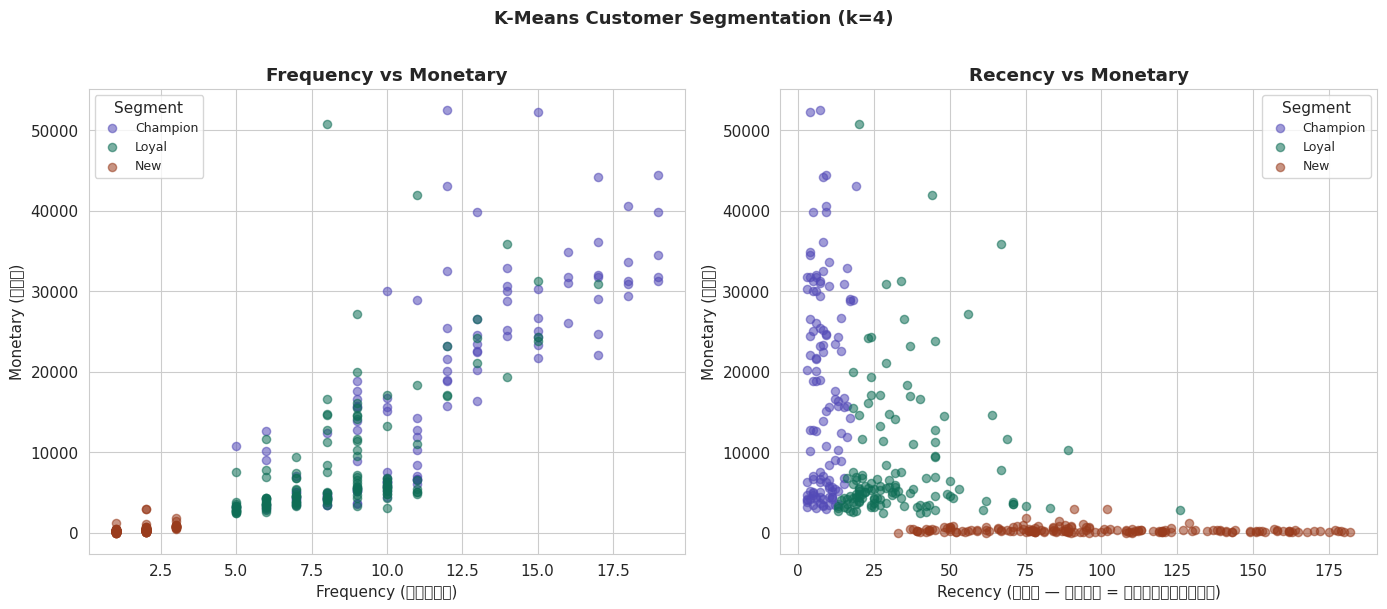

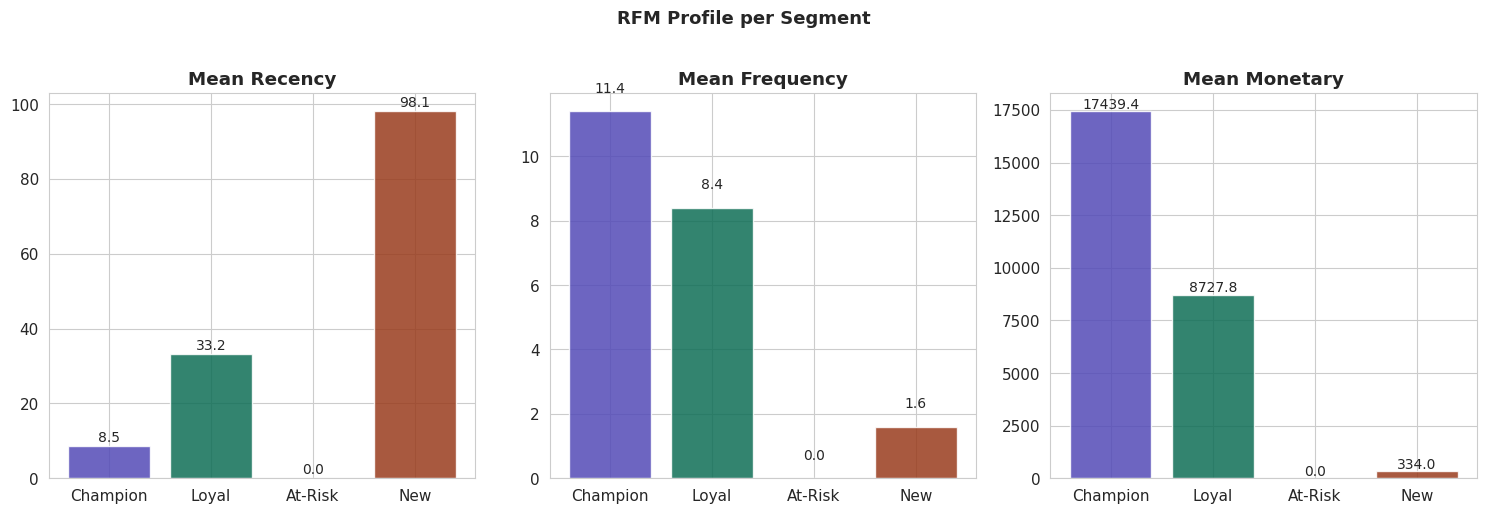

✅ Charts บันทึกแล้ว


In [39]:
print("\n" + "─" * 50)
print("  SECTION 5 — Visualize Segments")
print("─" * 50)

seg_color_map = {
    'Champion': COLORS[0], 'Loyal'  : COLORS[1],
    'At-Risk' : COLORS[2], 'New'    : COLORS[3]
}
seg_order = ['Champion', 'Loyal', 'At-Risk', 'New']

# Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for seg, grp in rfm.groupby('segment'):
    axes[0].scatter(grp['frequency'], grp['monetary'],
                    color=seg_color_map[seg], alpha=0.55,
                    s=35, label=seg)
    axes[1].scatter(grp['recency'], grp['monetary'],
                    color=seg_color_map[seg], alpha=0.55,
                    s=35, label=seg)

axes[0].set_xlabel('Frequency (ครั้ง)')
axes[0].set_ylabel('Monetary (บาท)')
axes[0].set_title('Frequency vs Monetary', fontweight='bold')
axes[0].legend(title='Segment', fontsize=9)

axes[1].set_xlabel('Recency (วัน — น้อย = ซื้อล่าสุด)')
axes[1].set_ylabel('Monetary (บาท)')
axes[1].set_title('Recency vs Monetary', fontweight='bold')
axes[1].legend(title='Segment', fontsize=9)

plt.suptitle('K-Means Customer Segmentation (k=4)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('diagrams/02_cluster_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

# Segment Profile Bar Chart
rfm_profile = rfm.groupby('segment')[features].mean().round(1)
fig, axes   = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, features):
    vals  = [rfm_profile.loc[s, col] if s in rfm_profile.index else 0
             for s in seg_order]
    bars  = ax.bar(seg_order, vals, color=COLORS, alpha=0.85, edgecolor='white')
    ax.set_title(f'Mean {col.capitalize()}', fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5,
                f'{v:.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('RFM Profile per Segment',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('diagrams/02_segment_profile.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Charts บันทึกแล้ว")

# 6. Segment Summary Table

In [40]:
print("\n" + "─" * 50)
print("  SECTION 6 — Segment Summary Table")
print("─" * 50)

summary = rfm.groupby('segment').agg(
    n_customers  = ('customer_id', 'count'),
    avg_recency  = ('recency',     'mean'),
    avg_freq     = ('frequency',   'mean'),
    avg_monetary = ('monetary',    'mean'),
).round(1)
summary['pct'] = (summary['n_customers'] /
                  summary['n_customers'].sum() * 100).round(1)

# เรียงตาม seg_order ที่มีอยู่จริง
available_segs = [s for s in seg_order if s in summary.index]

print(f"\n{'Segment':<12} {'Count':>7} {'%':>6} "
      f"{'Recency':>10} {'Freq':>8} {'Monetary':>10}")
print("─" * 58)
for seg in available_segs:
    r = summary.loc[seg]
    print(f"{seg:<12} {int(r['n_customers']):>7} {r['pct']:>5.1f}% "
          f"{r['avg_recency']:>10.1f} {r['avg_freq']:>8.1f} "
          f"{r['avg_monetary']:>10.1f}")

desc = {
    'Champion': 'ซื้อล่าสุด ซื้อบ่อย ใช้จ่ายสูง → รักษาด้วยโปร VIP',
    'Loyal'   : 'ซื้อสม่ำเสมอ → กระตุ้นให้ upgrade ขึ้น Champion',
    'At-Risk' : 'ไม่ได้ซื้อนาน → เร่ง re-engage ก่อนหายไป',
    'New'     : 'เพิ่งเริ่มซื้อ → สร้าง loyalty ด้วยโปรต้อนรับ',
}
print("\n📋 Business Description:")
for seg, d in desc.items():
    print(f"  {seg:<10}: {d}")


──────────────────────────────────────────────────
  SECTION 6 — Segment Summary Table
──────────────────────────────────────────────────

Segment        Count      %    Recency     Freq   Monetary
──────────────────────────────────────────────────────────
Champion         120  28.8%        8.5     11.4    17439.4
Loyal            131  31.5%       33.2      8.4     8727.8
New              165  39.7%       98.1      1.6      334.0

📋 Business Description:
  Champion  : ซื้อล่าสุด ซื้อบ่อย ใช้จ่ายสูง → รักษาด้วยโปร VIP
  Loyal     : ซื้อสม่ำเสมอ → กระตุ้นให้ upgrade ขึ้น Champion
  At-Risk   : ไม่ได้ซื้อนาน → เร่ง re-engage ก่อนหายไป
  New       : เพิ่งเริ่มซื้อ → สร้าง loyalty ด้วยโปรต้อนรับ


# 7. Validate กับ True Segment

In [41]:
import pandas as pd

print("🔍 กำลังดึงข้อมูล True Segment จากตารางลูกค้ามาเทียบ...")

try:
    # 1. โหลดไฟล์ลูกค้า (ที่มีข้อมูลเฉลยกลุ่มตอนทำ Mock Data)
    customers = pd.read_csv('customer_master.csv')

    # 2. เช็กว่ามีคอลัมน์ true_segment อยู่ในนั้นไหม
    if 'true_segment' in customers.columns:
        # 3. นำมาประกอบร่าง (Merge) กับตาราง rfm ของเราโดยเชื่อมกันด้วยรหัสลูกค้า
        rfm = rfm.merge(customers[['customer_id', 'true_segment']], on='customer_id', how='left')
        print("✅ ดึงข้อมูล true_segment มาเชื่อมกับตาราง rfm เรียบร้อยแล้ว")

        display(rfm[['customer_id', 'segment', 'true_segment']].head())
    else:
        print("⚠️ ในไฟล์ customer_master.csv ไม่มีคอลัมน์ true_segment")
        print("💡 ในงานจริงเราก็ไม่มีเฉลยให้เทียบอยู่แล้ว สามารถข้าม Section 7 นี้ไปได้เลยค่ะ")

except FileNotFoundError:
    print("❌ หาไฟล์ customer_master.csv ไม่เจอ อย่าลืมอัปโหลดไฟล์")

🔍 กำลังดึงข้อมูล True Segment จากตารางลูกค้ามาเทียบ...
✅ ดึงข้อมูล true_segment มาเชื่อมกับตาราง rfm เรียบร้อยแล้ว


,customer_id,segment,true_segment
0,C0001,New,At-Risk
1,C0002,Champion,Loyal
2,C0003,Loyal,Loyal
3,C0004,New,New
4,C0005,Loyal,Loyal



──────────────────────────────────────────────────
  SECTION 7 — Validate กับ True Segment
──────────────────────────────────────────────────


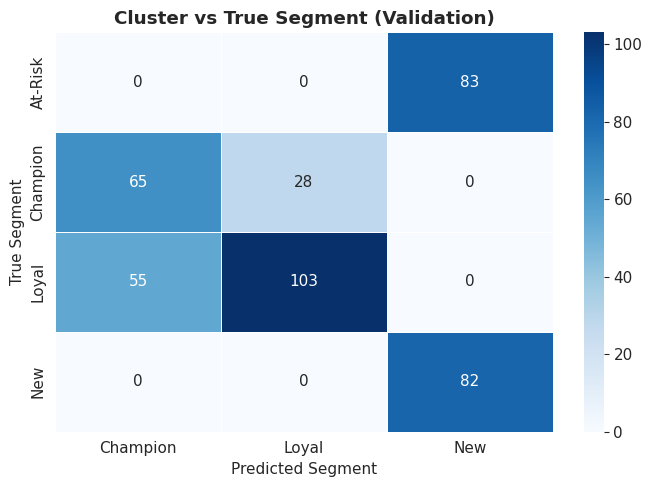


💡 อ่านผล:
   ค่าสูงบนแนวทแยง = clustering แม่นยำ
   ค่าสูงนอกแนวทแยง = บางกลุ่มถูก mis-classify
Predicted Segment  Champion  Loyal  New
True Segment                           
At-Risk                   0      0   83
Champion                 65     28    0
Loyal                    55    103    0
New                       0      0   82


In [42]:
print("\n" + "─" * 50)
print("  SECTION 7 — Validate กับ True Segment")
print("─" * 50)

cross = pd.crosstab(
    rfm['true_segment'], rfm['segment'],
    rownames=['True Segment'], colnames=['Predicted Segment']
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Cluster vs True Segment (Validation)', fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/02_validation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n💡 อ่านผล:")
print("   ค่าสูงบนแนวทแยง = clustering แม่นยำ")
print("   ค่าสูงนอกแนวทแยง = บางกลุ่มถูก mis-classify")
print(cross)

# 8. Save Output

In [43]:
print("\n" + "─" * 50)
print("  Save Output")
print("─" * 50)

out_cols = ['customer_id', 'recency', 'frequency', 'monetary', 'segment']
rfm[out_cols].to_csv('data/processed/rfm_clustered.csv', index=False)

print(f"\n✅ บันทึก rfm_clustered.csv")
print(f"   {len(rfm)} customers × {len(out_cols)} columns")
print(f"   Columns: {out_cols}")
print("\n→ ต่อไป: 03_regression.py (Layer 2)")
print("=" * 50)


──────────────────────────────────────────────────
  Save Output
──────────────────────────────────────────────────

✅ บันทึก rfm_clustered.csv
   500 customers × 5 columns
   Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'segment']

→ ต่อไป: 03_regression.py (Layer 2)
